# Project: Multi-Omics Integration for Personalised Medicine

This Jupyter notebook will guide you through the project in the Introduction to Multi-Omics Integration and Visualisation course at EMBL-EBI. You'll explore how to use Multi-Omics Factor Analysis (MOFA) to analyze a dataset of Chronic Lymphocytic Leukemia patients. All practical exercises will take place within this notebook, ensuring you have everything you need in one place.

In [1]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import mofaflex as mfl
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import decoupler as dc

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



## Prerequisites

Before getting started, ensure you're familiar with some key Python packages used in this project. The links below provide helpful introductions.

### NumPy
A library for numerical computing, providing the np.array class for vector and matrix operations. In this project, numerical data (e.g., mRNA counts) will typically be stored as NumPy arrays.

[NumPy Quickstart](https://numpy.org/doc/stable/user/quickstart.html)

### Pandas
A powerful library for working with tabular data, offering the pd.DataFrame class. Unlike NumPy arrays, DataFrames allow labeled columns and rows, support multiple data types (e.g., integers and strings), and enable easy indexing by name.

[10 minutes to Pandas](https://pandas.pydata.org/docs/user_guide/10min.html)

### Matplotlib
The most widely used plotting library in Python. While mastering it takes time, this guide covers the essentials.

[Matplotlib Quick Start Guide](https://matplotlib.org/stable/users/explain/quick_start.html)

## Data handling

Now that you're prepared, let's dive into handling Omics and Multi-Omics data in Python. While you could work with standard arrays and DataFrames, a more specialized data structure exists: AnnData. You'll get familiar with it in the following section.

### AnnData

If you've worked with R, you probably know the SingleCellExperiment or SummarizedExperiment classes. AnnData is pretty much the same, but in Python.

<img src="graphics/anndata_schema.svg" alt="drawing" width="400"/>

An AnnData object has several key attributes:
- .X: The main data matrix, typically a count matrix with dimensions (n_observations × n_variables).
- .obs: A DataFrame containing metadata for each observation (row in .X), such as cell type or donor ID. Its index column can be accessed directly via .obs_names.
- .var: A DataFrame containing metadata for each variable (column in .X), such as a gene’s genomic location. Its index column can be accessed via .var_names.
- .obsm: A dictionary storing multi-dimensional observation data. Unlike .obs, which holds one-dimensional metadata (e.g., cell types), .obsm can store structured data like 2D UMAP coordinates or PCA components.
- .varm: The equivalent of .obsm for storing additional metadata related to variables.
- .layers: A dictionary for storing multiple versions of the data matrix (same shape as .X). This is useful for preserving raw counts while working with transformed versions (e.g., log-transformed data).
- .uns: A dictionary for miscellaneous information that doesn’t fit into observations or variables, such as dataset metadata or author contact details.
- .obsp & .varp: Rarely used; not covered in this guide.

Browse [AnnData Getting Started](https://anndata.readthedocs.io/en/latest/tutorials/notebooks/getting-started.html) to learn more!

Now, let's dive into some actual code! We'll start by downloading an example AnnData object included in the ScanPy package, a powerful Python library for single-cell analysis. If you're interested in learning more, I highly recommend checking out the [ScanPy tutorials](https://scanpy.readthedocs.io/en/stable/tutorials/index.html).

In [2]:
adata = sc.datasets.pbmc3k_processed()
adata

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

#### Exercise
Take a closer look at the AnnData object and see what you can learn about the dataset. Answer the following questions, and if you need a hand, feel free to ask your favorite large language model (that's what they're here for!).

1. How many cells and genes are in the dataset?
2. Does .X contain raw mRNA counts, or has the data been processed in some way?
3. Examine the 'louvain' column in the .obs DataFrame. What information does it store, and how many unique values does it contain?
4. Find the PCA (Principal Component Analysis) projection of the data. How many components are included?
5. Visualizing embeddings:
    - Create a 2D scatter plot of the UMAP embedding using Matplotlib.
    - Compare it to the t-SNE embedding—do they look similar?
    - Color the dots by cell type.
    - Generate a plot showing only one cell type (subset the AnnData object before plotting).
    - Try using ScanPy’s built-in plotting functions instead of Matplotlib.


In [3]:
# Exercise 1

print("Number of cells:", adata.n_obs)
print("Number of genes:", adata.n_vars)

Number of cells: 2638
Number of genes: 1838


In [4]:
# Exercise 2

# print the values of the first 10 cells and genes
print(adata.X[:10, :10])

[[-0.17146951 -0.28081203 -0.04667679 -0.4751688  -0.54402375  4.9284954
  -0.03802771 -0.28057286 -0.34178796 -0.19536126]
 [-0.21458222 -0.37265295 -0.05480444 -0.68339145  0.6339506  -0.33483657
  -0.04558872 -0.49826393 -0.5419136  -0.20901662]
 [-0.37688747 -0.2950843  -0.0575275  -0.52097213  1.3326473  -0.30936235
  -0.10310837 -0.2725262  -0.50079846 -0.22022834]
 [-0.2852409  -0.2817346  -0.05222673 -0.48492876  1.5726788  -0.27182466
  -0.07455207 -0.25887555 -0.41675165 -0.20847097]
 [-0.2564834  -0.220394   -0.04680008 -0.34585932 -0.33340898 -0.20812184
  -0.06951413  5.806442   -0.2831118  -0.19935483]
 [-0.27125517 -0.26451087 -0.0504178  -0.44547978 -0.49266204 -0.25229883
  -0.07123657 -0.2192935  -0.3754224  -0.20523469]
 [-0.09565778 -0.27648515 -0.04273415 -0.4603669  -0.5231178  -0.2144933
  -0.01394444 -0.2858648   2.661892   -0.18627307]
 [-0.15813293 -0.27562705 -0.04569191 -0.46267566 -0.52448225  3.6938033
  -0.03409468 -0.2705804  -0.3234718  -0.19334242]
 [ 

In [5]:
# Exercise 3

print(adata.obs["louvain"].unique())

['CD4 T cells', 'B cells', 'CD14+ Monocytes', 'NK cells', 'CD8 T cells', 'FCGR3A+ Monocytes', 'Dendritic cells', 'Megakaryocytes']
Categories (8, object): ['CD4 T cells', 'CD14+ Monocytes', 'B cells', 'CD8 T cells', 'NK cells', 'FCGR3A+ Monocytes', 'Dendritic cells', 'Megakaryocytes']


In [6]:
# Exercise 4

print(adata.obsm["X_pca"].shape) # (number of cells, number of principal components)

(2638, 50)


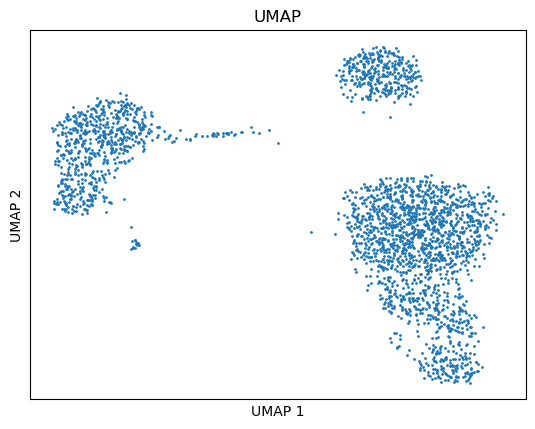

In [7]:
# Exercise 5a

plt.scatter(x=adata.obsm["X_umap"][:, 0], y=adata.obsm["X_umap"][:, 1], s=1)
plt.title("UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.xticks([])
plt.yticks([])
plt.show()

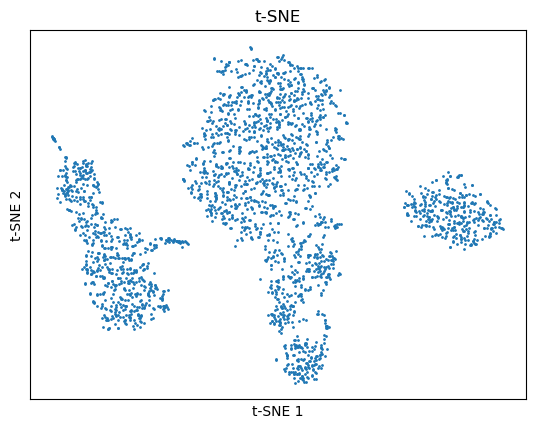

In [8]:
# Exercise 5b

plt.scatter(adata.obsm["X_tsne"][:, 0], adata.obsm["X_tsne"][:, 1], s=1)
plt.title("t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.xticks([])
plt.yticks([])
plt.show()

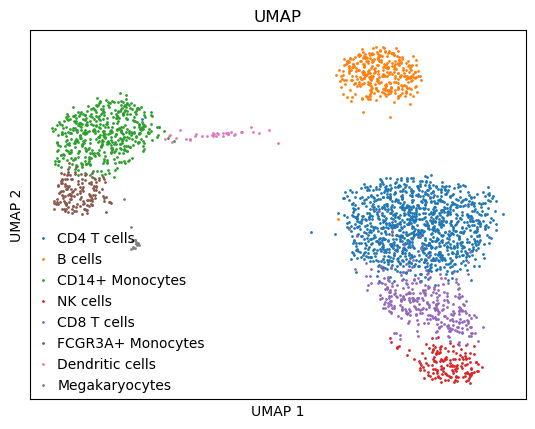

In [9]:
# Exercise 5c

fig, ax = plt.subplots()

for celltype in adata.obs["louvain"].unique():
    adata_celltype = adata[adata.obs["louvain"] == celltype]
    ax.scatter(adata_celltype.obsm["X_umap"][:, 0], adata_celltype.obsm["X_umap"][:, 1], s=1, label=celltype)

ax.set_title("UMAP")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_xticks([])
ax.set_yticks([])
plt.legend()
plt.show()

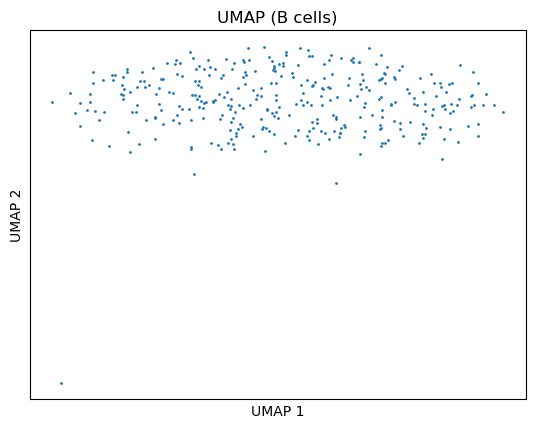

In [10]:
# Exercise 5d

adata_B_cells = adata[adata.obs["louvain"] == "B cells"]

plt.scatter(adata_B_cells.obsm["X_umap"][:, 0], adata_B_cells.obsm["X_umap"][:, 1], s=1)
plt.title("UMAP (B cells)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.xticks([])
plt.yticks([])
plt.show()

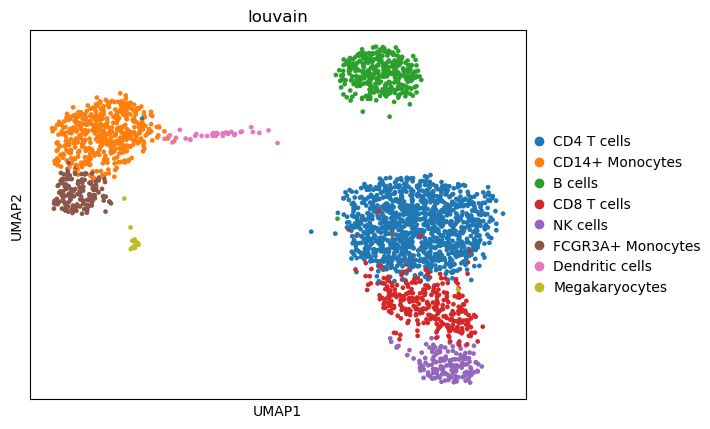

In [11]:
# Exercise 5e

sc.pl.umap(adata, color="louvain")

You're probably eager to analyze your own data! In the next section, we'll explore how to create an AnnData object from a common file format: CSV. If you need to load data from other formats, check out the [ScanPy reading functions](https://scanpy.readthedocs.io/en/stable/api/reading.html). (Fun fact: ScanPy even has a built-in CSV reader, but we won’t use it here to keep things a little more hands-on!)

We'll start by exploring the Chronic Lymphocytic Leukemia (CLL) dataset, focusing on a single modality: transcriptome measurements. Before diving into the code, open the CSV file in a text editor to see how it's structured.

Now, let's begin by loading the file as a Pandas DataFrame:

In [12]:
mrna_df = pd.read_csv("data/cll_mrna.csv", index_col=0).T

mrna_df

,ENSG00000244734,ENSG00000158528,ENSG00000198478,ENSG00000175445,ENSG00000174469,ENSG00000188536,ENSG00000186522,ENSG00000196263,ENSG00000198046,ENSG00000144642,...,ENSG00000136492,ENSG00000143198,ENSG00000161653,ENSG00000203778,ENSG00000177599,ENSG00000111328,ENSG00000165474,ENSG00000164061,ENSG00000166816,ENSG00000165972
H045,4.558644,11.741854,8.921456,12.686458,2.644946,2.644946,11.473792,9.680574,10.323723,11.137333,...,7.220013,10.177649,4.667130,7.052534,6.323287,10.059942,1.528848,5.771337,1.528848,5.256267
H109,2.721512,13.287432,2.721512,10.925985,12.648355,1.528848,10.271483,9.986980,10.231973,1.528848,...,7.947078,8.223803,4.775046,6.279164,5.799820,10.361200,1.528848,5.359180,2.383843,7.360436
H024,9.938456,2.341006,12.381452,1.528848,1.528848,6.664661,3.408744,3.657904,3.657904,2.341006,...,8.967320,10.096502,5.815616,6.369060,6.539086,8.152703,1.528848,6.059008,2.341006,5.715771
H056,13.278004,3.232874,8.106266,1.528848,13.565210,9.580385,3.410471,3.565827,3.232874,2.417160,...,8.532982,10.238564,5.902633,5.728777,5.929667,7.737858,2.417160,5.495087,3.232874,5.789100
H079,6.086874,11.940820,4.889503,13.340588,5.476914,3.862678,9.955379,10.244702,10.567114,7.967849,...,7.760580,8.790501,5.929477,5.833956,6.036300,8.274131,2.270282,5.102382,1.528848,6.316072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H070,3.254823,1.528848,1.528848,4.436292,12.418931,1.528848,1.528848,1.528848,1.528848,1.528848,...,8.410700,9.314123,4.956979,6.873084,6.070732,8.067587,1.528848,5.111537,1.528848,7.060619
H255,3.269304,12.427299,2.907226,11.425088,1.528848,2.344369,9.696142,10.988039,10.060879,5.343396,...,6.579472,10.558828,5.043407,6.954905,5.874135,8.751176,1.528848,5.726740,2.667779,5.986365
H135,1.528848,1.528848,1.528848,1.528848,12.815852,1.528848,1.528848,1.528848,1.528848,1.528848,...,7.178759,9.572243,3.491024,6.028750,5.038032,8.350212,1.528848,6.936723,1.528848,5.756981
H247,8.826116,3.121428,8.087886,5.680739,9.970217,5.836520,1.528848,7.679473,2.682078,3.121428,...,7.243387,9.173220,4.317162,6.526577,4.165399,9.158571,1.528848,4.517548,1.528848,6.241231


We've successfully loaded the data as a Pandas DataFrame, ensuring that the zero-th column is recognized as the index. The gene names (row indices) and sample names (column headers) are already included, so we can now easily convert this DataFrame into an AnnData object.

In [13]:
mrna_adata = ad.AnnData(mrna_df)

mrna_adata

AnnData object with n_obs × n_vars = 136 × 5000

#### Exercise
1. Check the .obs_names and .var_names attributes. Do they match the DataFrame’s index and columns?
2. The previous overview didn’t show any .obs or .var entries. Can you still access them? Why might they be missing?
3. Load the data/cll_metadata.csv file into a Pandas DataFrame and inspect it. Make sure that the "Sample" column is the index. Then, try adding the "Age4Main" column to .obs. Notice that the metadata DataFrame has 265 rows, while the AnnData object only has 136. What does this mean? Do the sample names still align?
4. Subset the AnnData object to include only patients older than 70.
5. Load the data/cll_mutations.csv file and create another AnnData object. How many patients are included? Do they match the patients in the transcriptome data?

In [14]:
# Exercise 1

print(mrna_adata.obs_names[:10])
print((mrna_adata.obs_names == mrna_df.index).all())

print(mrna_adata.var_names[:10])
print((mrna_adata.var_names == mrna_df.columns).all())

Index(['H045', 'H109', 'H024', 'H056', 'H079', 'H164', 'H059', 'H167', 'H113',
       'H049'],
      dtype='object')
True
Index(['ENSG00000244734', 'ENSG00000158528', 'ENSG00000198478',
       'ENSG00000175445', 'ENSG00000174469', 'ENSG00000188536',
       'ENSG00000186522', 'ENSG00000196263', 'ENSG00000198046',
       'ENSG00000144642'],
      dtype='object')
True


In [15]:
# Exercise 2

print(mrna_adata.obs)
print(mrna_adata.var)

# the .obs and .var DataFrames exist, but they are currently empty

Empty DataFrame
Columns: []
Index: [H045, H109, H024, H056, H079, H164, H059, H167, H113, H049, H133, H103, H035, H121, H033, H064, H236, H238, H171, H018, H115, H117, H053, H148, H165, H114, H038, H240, H173, H187, H234, H060, H191, H118, H228, H100, H104, H054, H046, H099, H112, H110, H225, H019, H163, H233, H231, H111, H096, H042, H077, H088, H013, H031, H023, H017, H097, H057, H040, H010, H047, H105, H044, H030, H107, H094, H058, H028, H021, H119, H005, H016, H055, H080, H041, H043, H011, H102, H020, H014, H085, H022, H078, H015, H116, H029, H036, H072, H087, H095, H090, H108, H039, H083, H082, H073, H081, H027, H069, H101, ...]

[136 rows x 0 columns]
Empty DataFrame
Columns: []
Index: [ENSG00000244734, ENSG00000158528, ENSG00000198478, ENSG00000175445, ENSG00000174469, ENSG00000188536, ENSG00000186522, ENSG00000196263, ENSG00000198046, ENSG00000144642, ENSG00000022556, ENSG00000240563, ENSG00000105967, ENSG00000165810, ENSG00000134184, ENSG00000214787, ENSG00000095777, ENSG000001

In [16]:
# Exercise 3

metadata_df = pd.read_csv("data/cll_metadata.csv", index_col=0) # note that index_col=0 sets the 0th column as index
mrna_adata.obs["Age"] = metadata_df["Age4Main"] # automatically aligned because both DataFrames have the Sample ID as index

mrna_adata.obs

,Age
H045,90.731507
H109,85.465753
H024,NaN
H056,83.468493
H079,47.898630
...,...
H070,71.463014
H255,67.367123
H135,76.136986
H247,46.934247


In [17]:
# Exercise 4

mrna_older_than_70_adata = mrna_adata[mrna_adata.obs["Age"] > 70]
print(mrna_older_than_70_adata.n_obs)
mrna_older_than_70_adata.obs.head(10)

52


,Age
H045,90.731507
H109,85.465753
H056,83.468493
H164,73.260274
H103,70.742466
H035,79.487671
H064,71.016438
H238,74.501370
H171,73.046575
H115,72.460274


In [18]:
# Exercise 5
mutations_df = pd.read_csv("data/cll_mutations.csv", index_col=0).T

mutations_adata = ad.AnnData(mutations_df)
print(mutations_adata.n_obs)
print(np.intersect1d(mutations_adata.obs_names, mrna_adata.obs_names).shape[0])

200
136


#### Exercise

We'll now set up the AnnData objects that will be used for MOFA analysis throughout the project. This involves:

1. Creating AnnData objects for each modality (transcriptome, methylation, mutations, drug response).
2. Storing these objects in a dictionary.

##### Load the Metadata
Start by loading the metadata as before. We'll convert the categorical variables "Sex", "died" and "IGHV" to numerical values to deal with them more easily later.

In [19]:
metadata_df = pd.read_csv("data/cll_metadata.csv", index_col=0)

# assuming you called the DataFrame `metadata_df`
metadata_df.rename(columns={"Gender" : "Sex"}, inplace=True)
metadata_df.replace({"Sex" : {"m" : 0, "f" : 1}}, inplace=True)
metadata_df.replace({"died" : {False : 0, True : 1}}, inplace=True)
metadata_df.replace({"IGHV" : {"U" : 0, "M" : 1}}, inplace=True)
metadata_df.fillna(-1, inplace=True)

metadata_df

/var/folders/8j/6swtmv_s3zlbsygt04f92_480000gp/T/ipykernel_23125/1497086161.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/var/folders/8j/6swtmv_s3zlbsygt04f92_480000gp/T/ipykernel_23125/1497086161.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/var/folders/8j/6swtmv_s3zlbsygt04f92_480000gp/T/ipykernel_23125/1497086161.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the f

,Diagnosis,Sex,IGHV,Age4Main,T5,T6,treatedAfter,died,IC50beforeTreatment,ConsClust
Sample,,,,,,,,,,
H001,hMNC,-1.0,-1.0,-1.000000,-1.000000,-1.000000,-1,-1.0,-1,-1
H002,hMNC,-1.0,-1.0,-1.000000,-1.000000,-1.000000,-1,-1.0,-1,-1
H003,hMNC,-1.0,-1.0,-1.000000,-1.000000,-1.000000,-1,-1.0,-1,-1
H005,CLL,0.0,1.0,75.265753,0.574949,2.625599,True,0.0,False,IP
H006,CLL,0.0,1.0,-1.000000,-1.000000,-1.000000,-1,-1.0,-1,HP
...,...,...,...,...,...,...,...,...,...,...
H276,AML,0.0,-1.0,61.838356,-1.000000,-1.000000,-1,-1.0,-1,-1
H277,AML,0.0,-1.0,82.578082,-1.000000,-1.000000,-1,-1.0,-1,-1
H278,AML,0.0,-1.0,75.290411,-1.000000,-1.000000,-1,-1.0,-1,-1


##### Load the Transcriptome Data
Next, load the transcriptome data as before. However, you might have noticed that the .var_names attribute contains ENSEMBL Gene IDs, while we want to use Gene Symbols instead.

The mapping between ENSEMBL IDs and Gene Symbols is stored in the cll_gene_ids.csv file. Some pre-written code is available to help with this conversion—go ahead and use it!

In [20]:
mrna_df = pd.read_csv("data/cll_mrna.csv", index_col=0).T
mrna_adata = ad.AnnData(mrna_df)

# assuming you called the AnnData object `adata_mrna`
gene_ids = pd.read_csv(os.path.join("data/cll_gene_ids.csv"), index_col=0)
cols = list(mrna_adata.var_names)
cols = [gene_ids.loc[gene_ids["GENEID"] == gene, "SYMBOL"].item() for gene in cols]
mrna_adata.var_names = cols

mrna_adata

AnnData object with n_obs × n_vars = 136 × 5000

##### Load the Mutations Data
Now, load the mutations data from data/cll_mutations.csv.

Since we’ll be combining multiple AnnData objects into a MuData object, each must have unique variable names. However, there's a potential issue: The .var_names in the mutations data may be gene names, which are already used in the transcriptome AnnData.

To avoid conflicts, some pre-written code automatically prepends "m_" to each variable name in the mutations data, ensuring uniqueness. Go ahead and apply this fix!

In [21]:
mutations_df = pd.read_csv("data/cll_mutations.csv", index_col=0).T
mutations_adata = ad.AnnData(mutations_df)

# assuming you called the AnnData object `adata_mutations`
mutations_adata.var_names = [f"m_{x}" for x in mutations_adata.var_names]

mutations_adata

AnnData object with n_obs × n_vars = 200 × 69

##### Load the Methylation Data
Next, load the methylation data from data/cll_methylation.csv.

In [22]:
methylation_df = pd.read_csv("data/cll_methylation.csv", index_col=0).T
methylation_adata = ad.AnnData(methylation_df)

methylation_adata

AnnData object with n_obs × n_vars = 200 × 4248

##### Load the Drug Response Data
Load the drug response data from data/cll_drugs.csv. This only contains the drug IDs, and we will replace them with the drug names using the pre-written code.

In [23]:
drugs_df = pd.read_csv("data/cll_drugs.csv", index_col=0).T
drugs_adata = ad.AnnData(drugs_df)

# assuming you called the AnnData object `adata_drugs`
drug_names = pd.read_csv("data/drugs.txt", sep=",", index_col=0)
mapping = drug_names["name"].to_dict()
cols = []
for k in drugs_adata.var_names:
    for v in mapping.keys():
        if v in k:
            cols.append(k.replace(v, mapping[v]))
            break

drugs_adata.var_names = cols

drugs_adata

AnnData object with n_obs × n_vars = 200 × 310

##### Combine Modalities and Load Metadata
Now that you’ve prepared all the AnnData objects, it's time to combine them into a dictionary! Create a dictionary `modality_dict`, where:
- The keys are the names of the individual modalities (e.g., "mrna", "methylation", "mutations", "drugs").
- The values are the corresponding AnnData objects.

In [24]:
modality_dict = {
    "mrna" : mrna_adata,
    "mutations" : mutations_adata,
    "methylation" : methylation_adata,
    "drugs" : drugs_adata
}

Well done. Data preparation is often the most time-consuming and challenging part of a data analysis project, but it sets the foundation for everything that follows. The next steps will be more focused on analysis and interpretation.

#### Exercise
Before moving forward, take some time to develop an intuition for the dataset.
1. Check for missing values: What percentage of values are missing in each modality? How many features does each modality contain?
2. Interpret the data matrix: What do the numerical values in each modality represent?
3. Visualize the data distribution: Use the histplot function from the seaborn package to plot the distribution of values for each modality. What should you expect this distribution to look like?

Understanding these aspects will help in making informed decisions during analysis.

In [25]:
# Exercise 1
print("Percentage of missing values in each modality:")
for modality in modality_dict.keys():
    print(modality, np.isnan(modality_dict[modality].X).mean())

print("Number of features in each modality:")
for modality in modality_dict.keys():
    print(modality, modality_dict[modality].n_vars)

Percentage of missing values in each modality:
mrna 0.0
mutations 0.33760869565217394
methylation 0.02
drugs 0.08
Number of features in each modality:
mrna 5000
mutations 69
methylation 4248
drugs 310


In [26]:
# Exercise 2
for modality in modality_dict.keys():
    print(modality, modality_dict[modality].X[:2, :2])

# mrna: transformed counts
# mutations: binary
# methylation: M-value
# drugs: viability score

mrna [[ 4.55864355 11.74185387]
 [ 2.72151227 13.28743173]]
mutations [[0. 0.]
 [0. 0.]]
methylation [[ 1.81108585 -5.17257225]
 [-3.99750846  1.59487016]]
drugs [[0.02363938 0.04623274]
 [0.073599   0.10623002]]


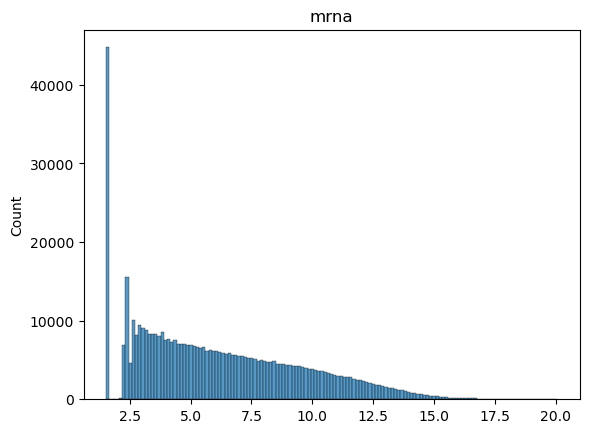

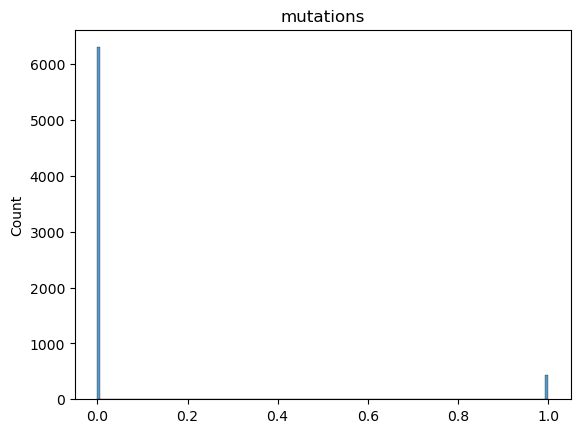

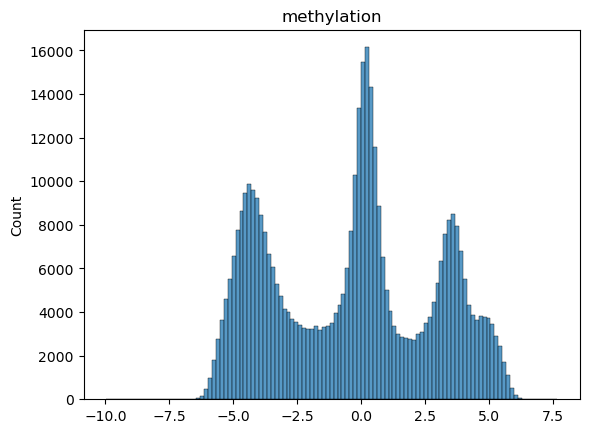

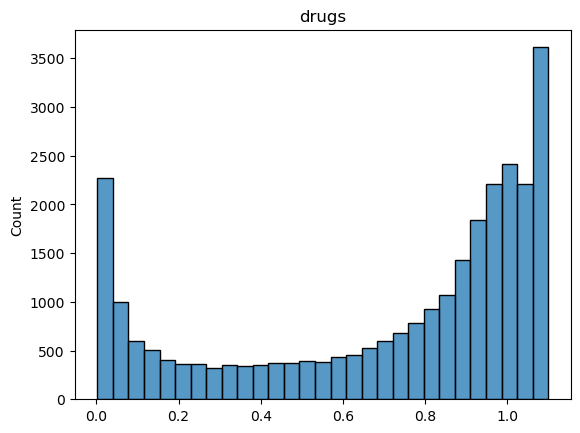

In [27]:
# Exercise 3
for modality in modality_dict.keys():
    fig, ax = plt.subplots()
    sns.histplot(modality_dict[modality].X[:100].flatten(), ax=ax) # just plot the first 100 samples
    ax.set_title(modality)
    plt.show()

## Training a MOFA-FLEX Model

Now that the data is prepared, we are ready to train the MOFA model. This step is straightforward thanks to the structured data format we have set up. While the original mofapy2 package can be used for this, a more convenient option is the new mofa-flex package.
In the next steps, we will train the MOFA model using mofa-flex and explore its results.

One last step for out data setup needs to be done though: Currently, we have a dictionary of AnnData objects where the keys denote the modality names and the values are the corresponding AnnData objects. MOFA-FLEX expects a nested dictionary though, where the first level keys represent the sample groups and the second level keys represent the modalities. In our case, we only have one sample group and therefore just call it "group_1".

/Users/fwalter/ebi_mofa_workshop/data_loader.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/Users/fwalter/ebi_mofa_workshop/data_loader.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/Users/fwalter/ebi_mofa_workshop/data_loader.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
WARNING	Device c

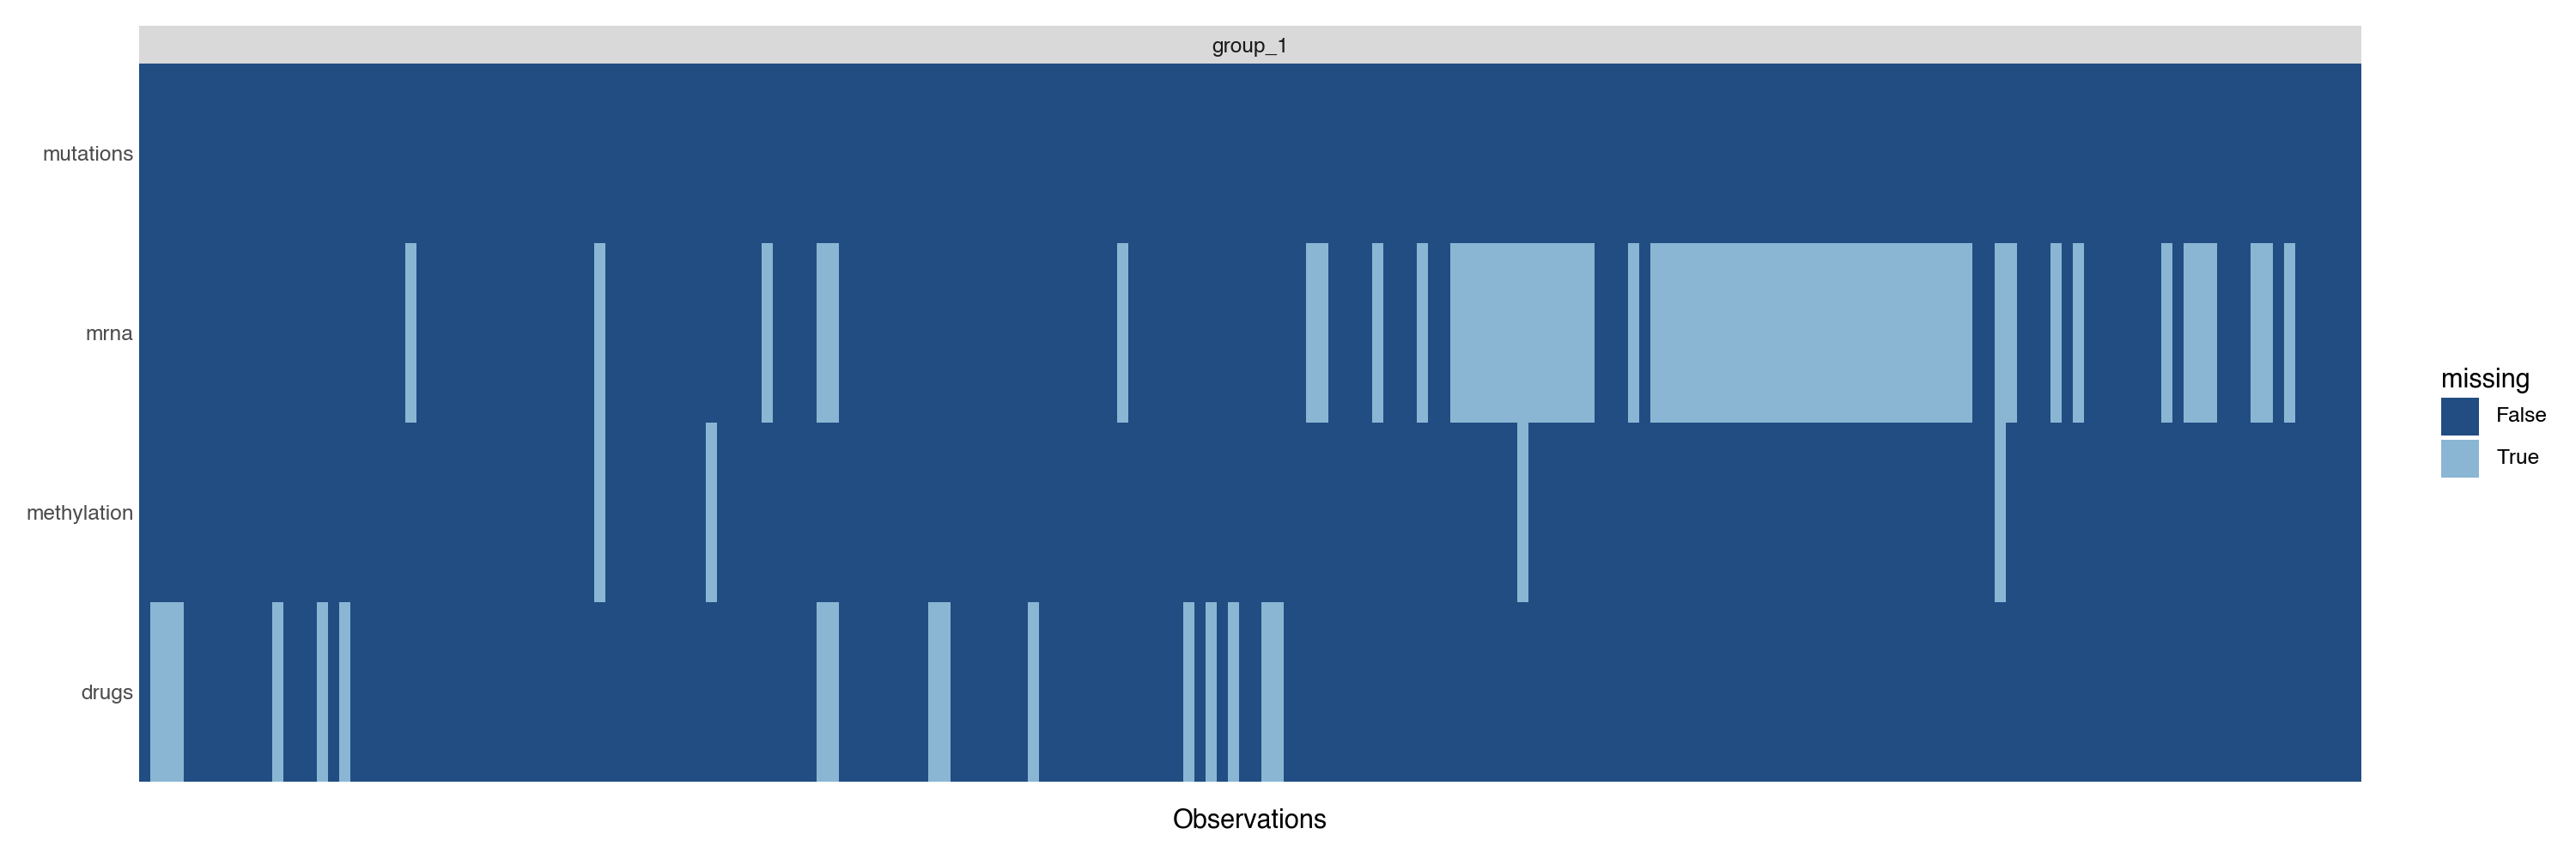

WARNING	Could not import dask. Data arrays may be copied, resulting in high memory usage.
/opt/homebrew/envs/mofaflex_workshop/lib/python3.13/site-packages/mofaflex/_core/utils.py:107: RuntimeWarning: Mean of empty slice
INFO	Initializing factors using `random` method...


  0%|                                             | 0/10000 [00:00<?, ?epochs/s]

2026-03-05 13:28:08 | [INFO] Guessed max_plate_nesting = 3
INFO	Training converged after 3883 epochs.
INFO	Saving results to models/mofaflex...
WARNING	models/mofaflex already exists, overwriting
/opt/homebrew/envs/mofaflex_workshop/lib/python3.13/site-packages/mofaflex/_core/io.py:77: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.


In [28]:
# if you're not sure about your prepared data dictionary, uncomment the following lines
from data_loader import load_cll
modality_dict = load_cll()

# MOFA-FLEX expects a nested dictionary, with sample group at the first level and modality at the second level.
data = {"group_1": modality_dict}

model = mfl.MOFAFLEX(
    data,
    mfl.DataOptions(
        plot_data_overview=True,
    ),
    mfl.ModelOptions(
        n_factors=10,
        weight_prior="Horseshoe",
        factor_prior="Normal",
        likelihoods="Normal",
    ),
    mfl.TrainingOptions(
        device="cuda:0",
        max_epochs=10000,
        lr=0.05,
        early_stopper_patience=1000,
        save_path=f"models/mofaflex",
        seed=1234,
    )
)

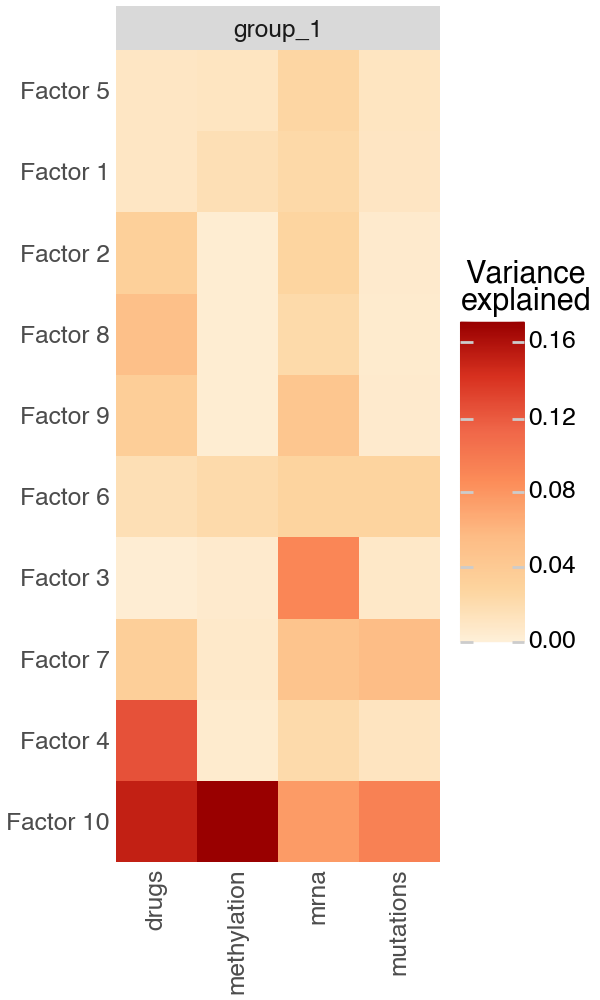

In [32]:
mfl.pl.variance_explained(model)

Examining the correlation of factor scores is also important. If two or more factors are highly correlated, they may be capturing the same underlying variation. In such cases, it might be reasonable to focus on just one of them to simplify the analysis without losing meaningful information.

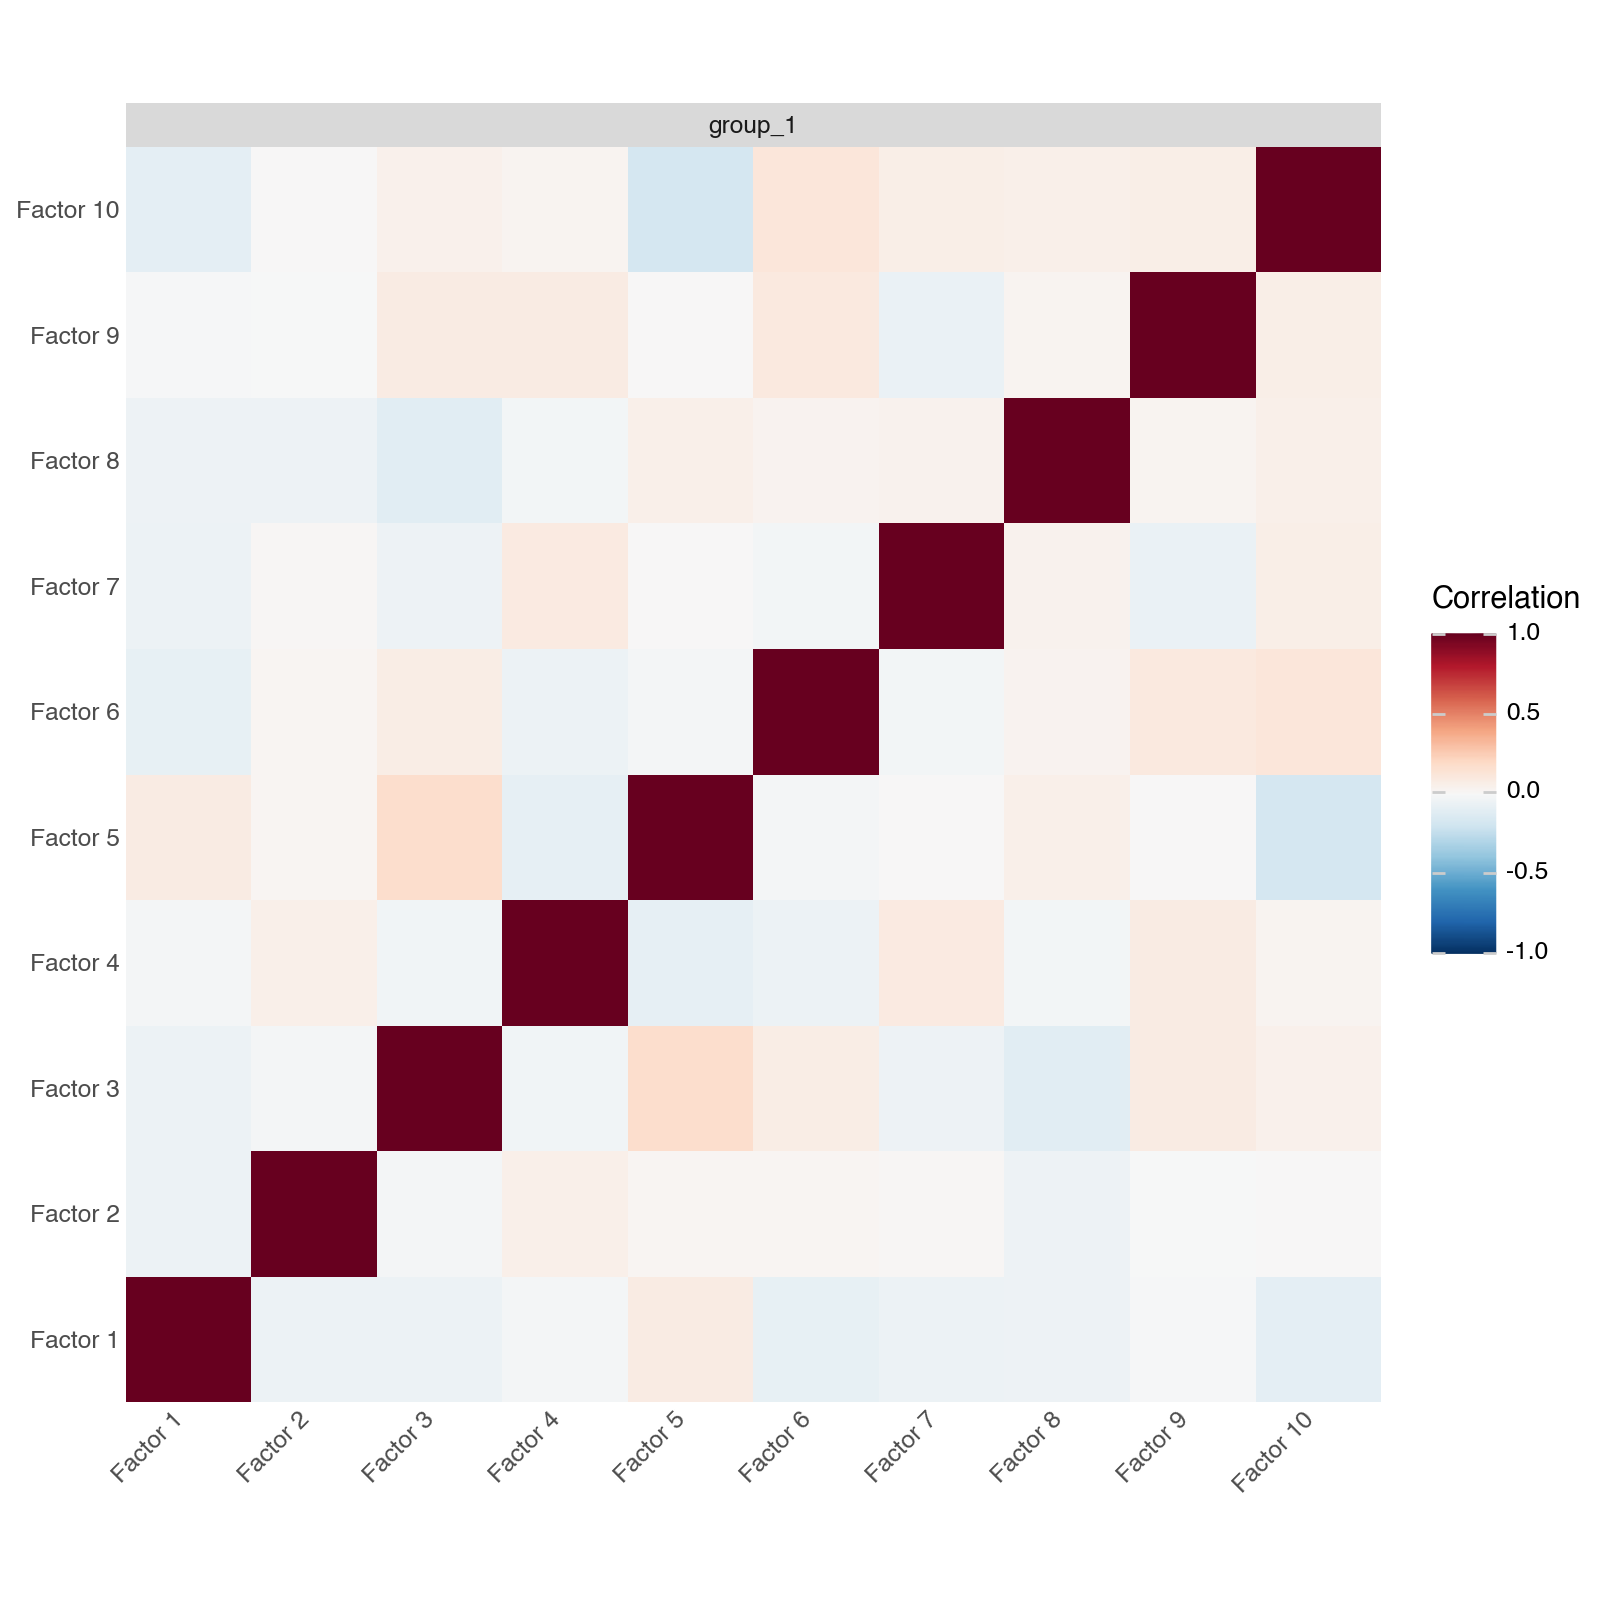

In [33]:
mfl.pl.factor_correlation(model)

#### Exercise

1. Train a second MOFA model with a different number of factors. Make sure to save it under a different name. Load the new model using mofax and re-plot the explained variance and factor score correlations. Do you observe similar patterns compared to the first model?
2. Compare total explained variance: How does the total explained variance change between the two models? Is the difference in variance explained consistent with what you expected?
3. Choosing the right number of factors:
   - Why is selecting too many factors problematic?
   - Why can too few factors limit the model’s usefulness?
   - What is the trade-off between interpretability and capturing meaningful variation?

Understanding these points will help optimize MOFA for meaningful biological insights.

WARNING	Device cuda:0 is not available. Using default device: cpu


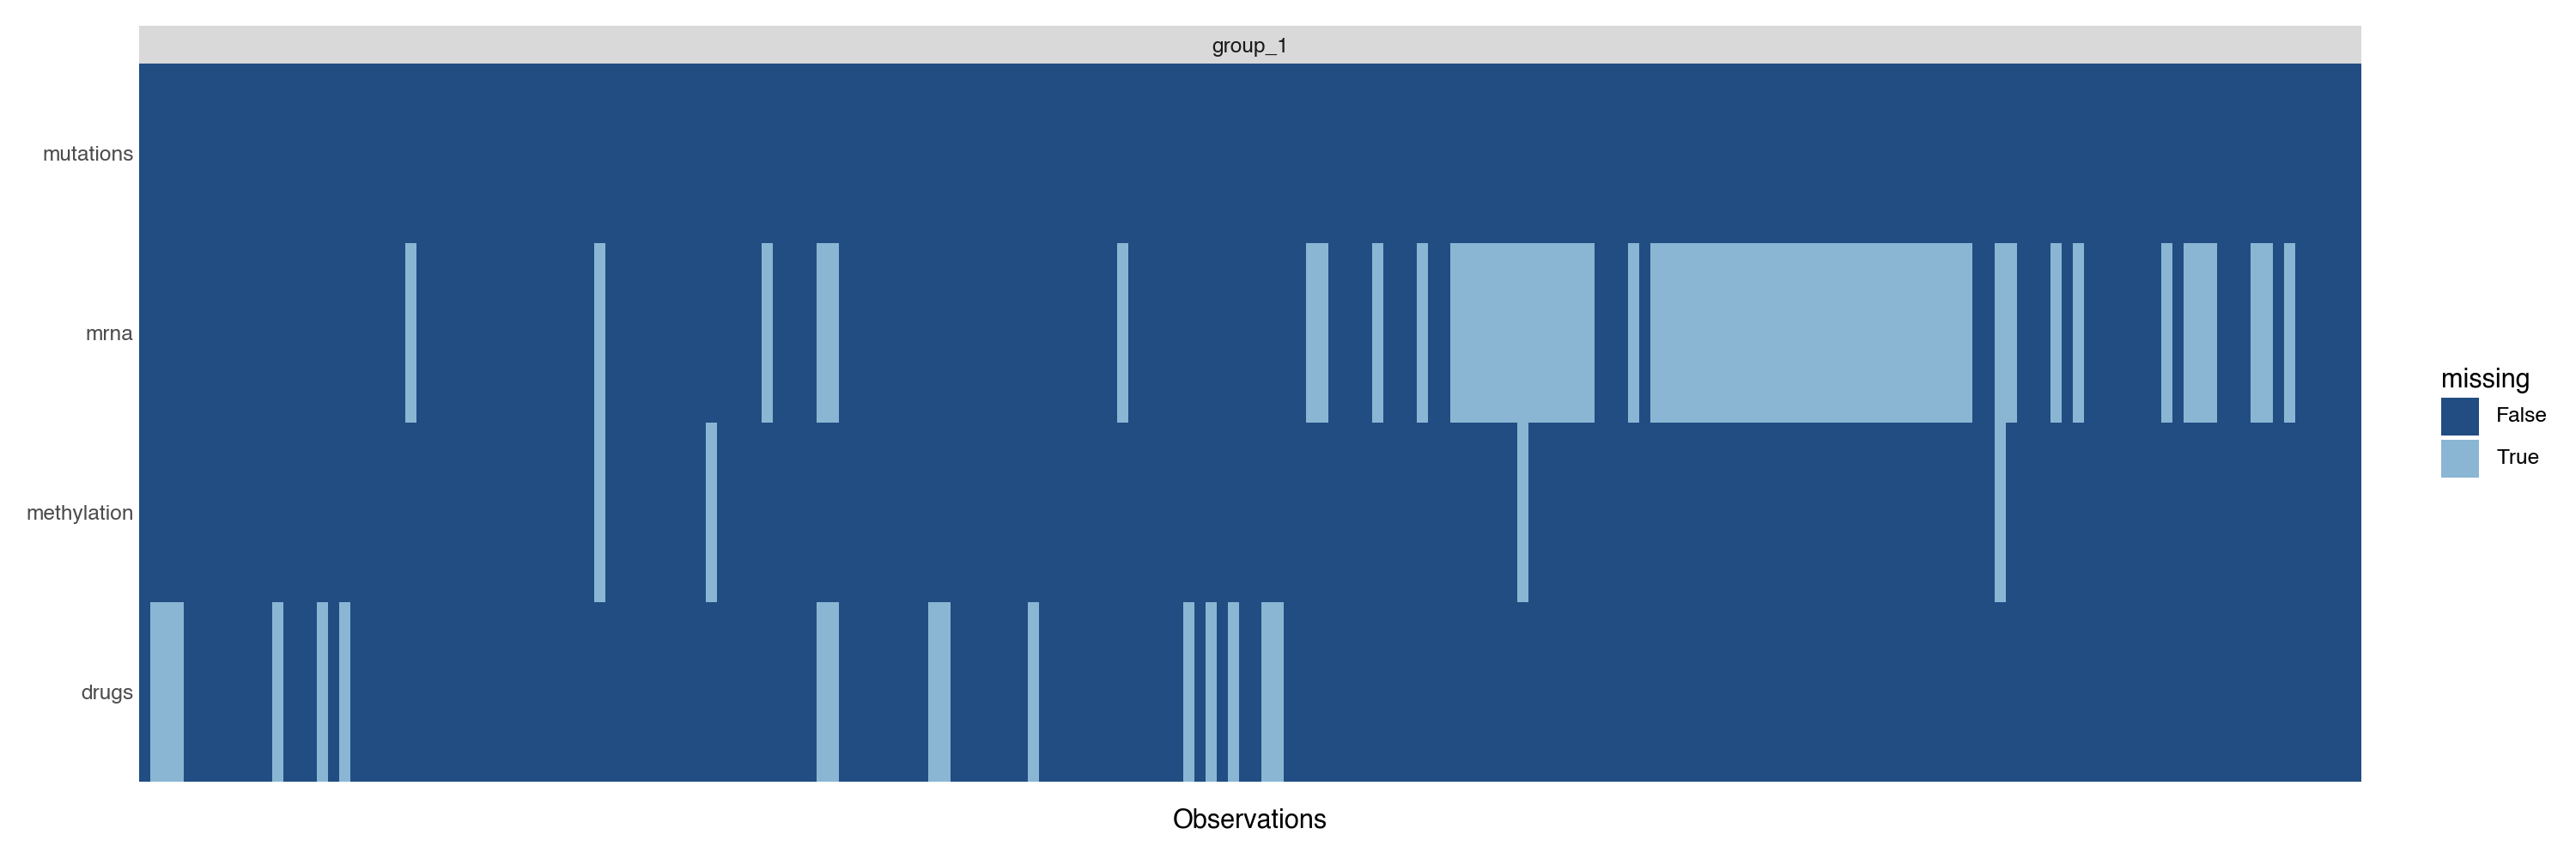

/opt/homebrew/envs/mofaflex_workshop/lib/python3.13/site-packages/mofaflex/_core/utils.py:107: RuntimeWarning: Mean of empty slice
INFO	Initializing factors using `random` method...


  0%|          | 0/10000 [00:00<?, ?epochs/s]

2026-03-01 14:33:57 | [INFO] Guessed max_plate_nesting = 3
INFO	Training converged after 4046 epochs.
INFO	Saving results to models/mofaflex_2...
WARNING	models/mofaflex_2 already exists, overwriting
/opt/homebrew/envs/mofaflex_workshop/lib/python3.13/site-packages/mofaflex/_core/io.py:77: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.


In [34]:
# Exercise 1

model_2 = mfl.MOFAFLEX(
    data,
    mfl.DataOptions(
        plot_data_overview=True,
    ),
    mfl.ModelOptions(
        n_factors=5,
        weight_prior="Horseshoe",
        factor_prior="Normal",
        likelihoods="Normal",
    ),
    mfl.TrainingOptions(
        device="cuda:0",
        max_epochs=10000,
        lr=0.05,
        early_stopper_patience=1000,
        save_path=f"models/mofaflex_2",
        seed=1234,
    )
)

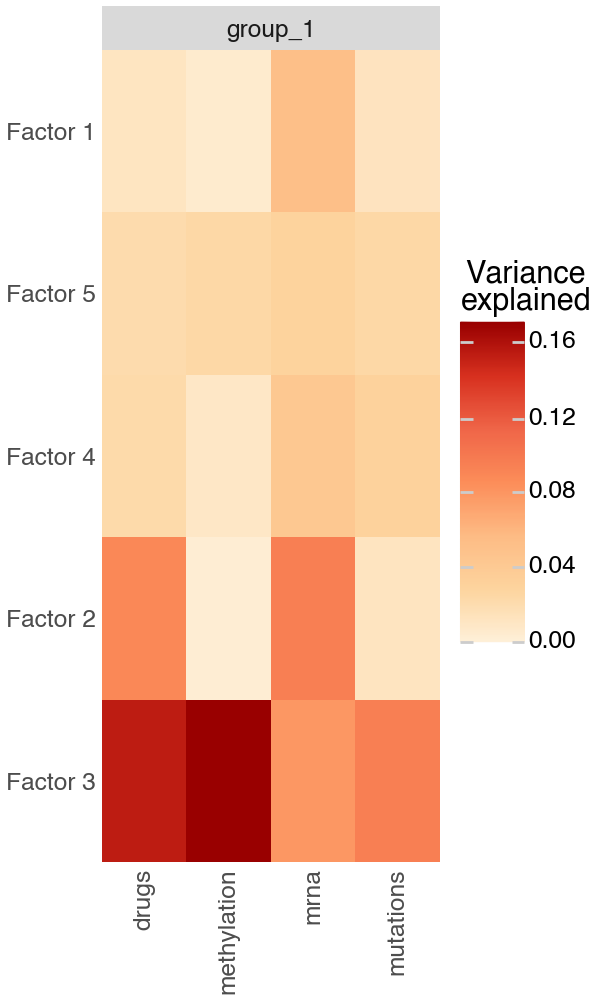

In [35]:
mfl.pl.variance_explained(model_2)

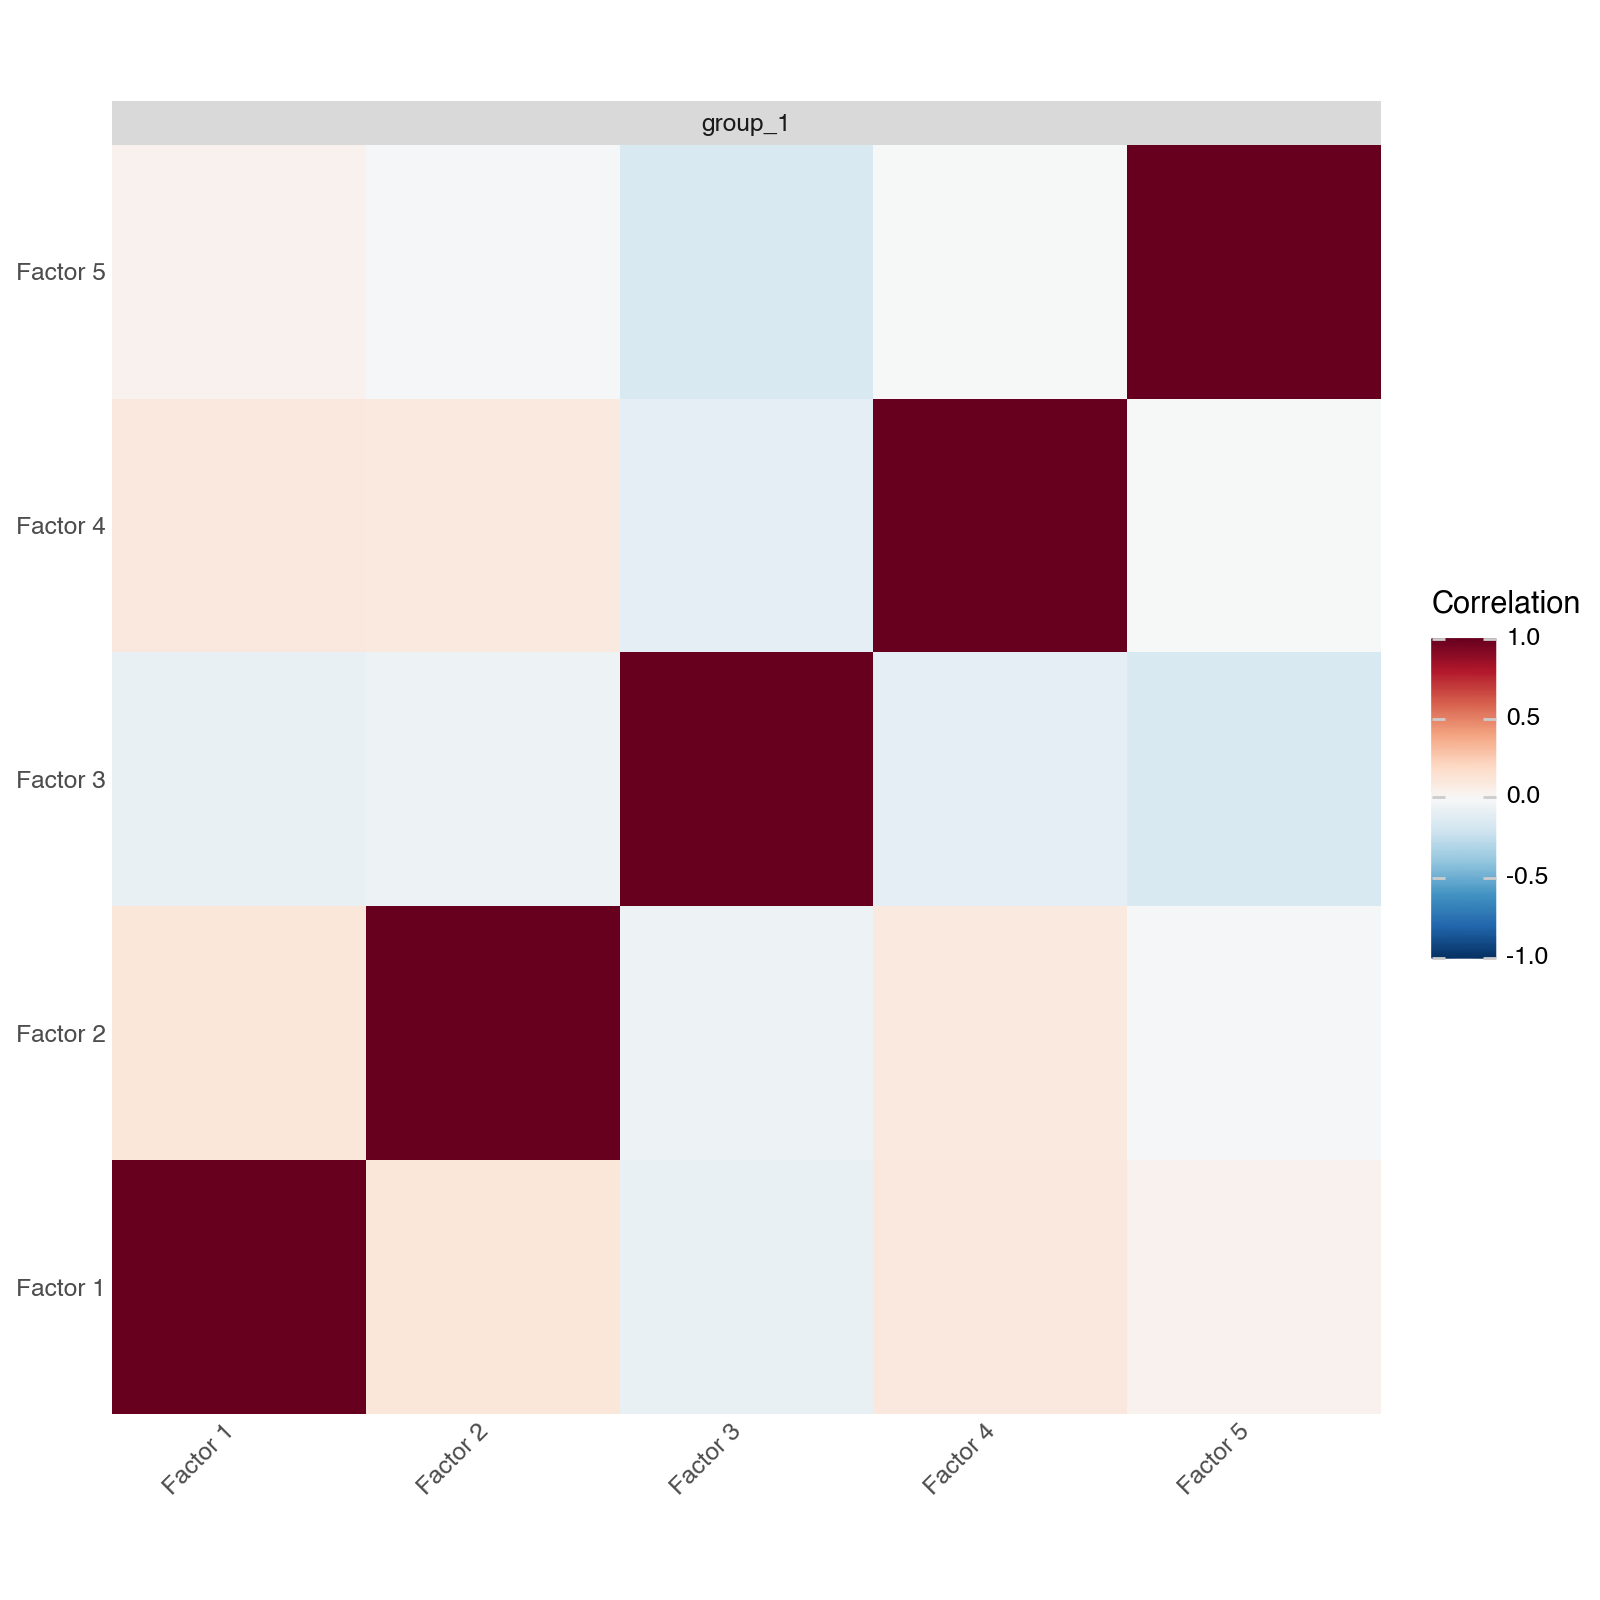

In [36]:
mfl.pl.factor_correlation(model_2)

In [37]:
# Exercise 2
print("Model with 10 factors:")
print(model.get_r2()["group_1"].sum(axis=0))
print("Model with 5 factors:")
print(model_2.get_r2()["group_1"].sum(axis=0))

Model with 10 factors:
mrna           0.412284
mutations      0.236930
methylation    0.251093
drugs          0.472211
dtype: float32
Model with 5 factors:
mrna           0.298928
mutations      0.176287
methylation    0.213787
drugs          0.299109
dtype: float32


In [38]:
# Exercise 3:
# too few factors lead to an underparameterised model that cannot explain the variation in the data
# too many factors lead to an overparameterised model that explains a lot of variation but does not efficiently reduce the dimensionality
# a model with fewer factors is more interpretable, while a model with more factors captures more variation

## Downstream Analysis Part I - Understanding the Factor Scores

The factor scores matrix has dimensions (n_samples × n_factors), meaning that for each sample, we have a set of inferred factor values. These scores capture patterns and variation in the multi-omics data.

You can extract the factor scores as a NumPy array, giving you full flexibility for custom analysis and visualization. However, both mofax and muon provide built-in plotting functions to simplify the process.

In the next steps, we will explore how to analyze and interpret these factor scores effectively.

In [39]:
factor_scores = model.get_factors()["group_1"]

factor_scores

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10
H045,0.013790,0.055516,0.137876,0.067009,0.099021,-0.073779,-0.019561,0.059213,0.019260,-0.207309
H109,-0.057387,-0.029068,0.041970,0.029987,0.089516,-0.022239,0.186645,-0.014478,-0.151723,-0.192644
H024,-0.088305,-0.085610,-0.080212,0.073322,-0.043621,-0.015204,-0.045694,-0.012618,0.187146,0.217522
H056,-0.062919,-0.032139,-0.083794,0.089969,-0.077215,0.067878,-0.041498,0.049121,0.118879,0.159555
H079,-0.014017,0.178784,0.118925,0.007748,-0.000153,-0.003744,-0.057902,-0.122792,-0.050128,-0.158300
...,...,...,...,...,...,...,...,...,...,...
H175,-0.018911,-0.002236,0.237434,0.073955,-0.004167,-0.012585,-0.027382,-0.070100,-0.077346,-0.210818
H179,-0.145420,0.161051,0.232991,0.038235,0.058810,-0.000011,-0.002143,-0.061372,0.062066,0.148391
H050,-0.017118,-0.056909,0.205185,0.039635,0.060293,-0.048897,0.017685,0.054865,-0.149962,0.330692
H180,-0.048558,-0.083497,0.075814,-0.010567,0.034053,-0.037390,0.099815,-0.197288,0.116071,-0.100296


We can visualize the factor scores using a heatmap:

<Axes: >

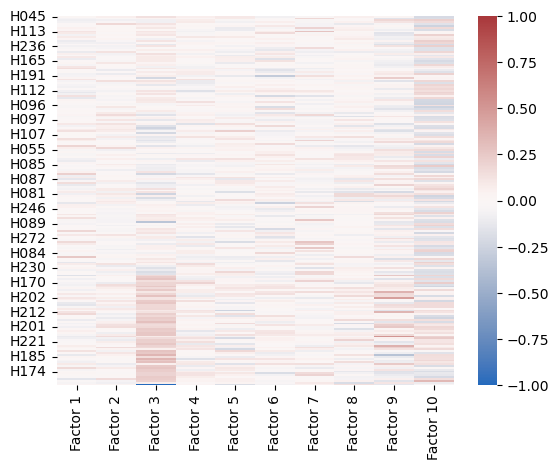

In [40]:
sns.heatmap(factor_scores, cmap="vlag", center=0, vmin=-1, vmax=1)

We can visualize the relationship between two individual factors by using the plot_factors_scatter function.

This scatter plot helps identify potential correlations or patterns between factors. If the points form a clear trend (e.g., linear or clustered patterns), it suggests a relationship between the selected factors. If no structure is visible, the factors may capture independent sources of variation.

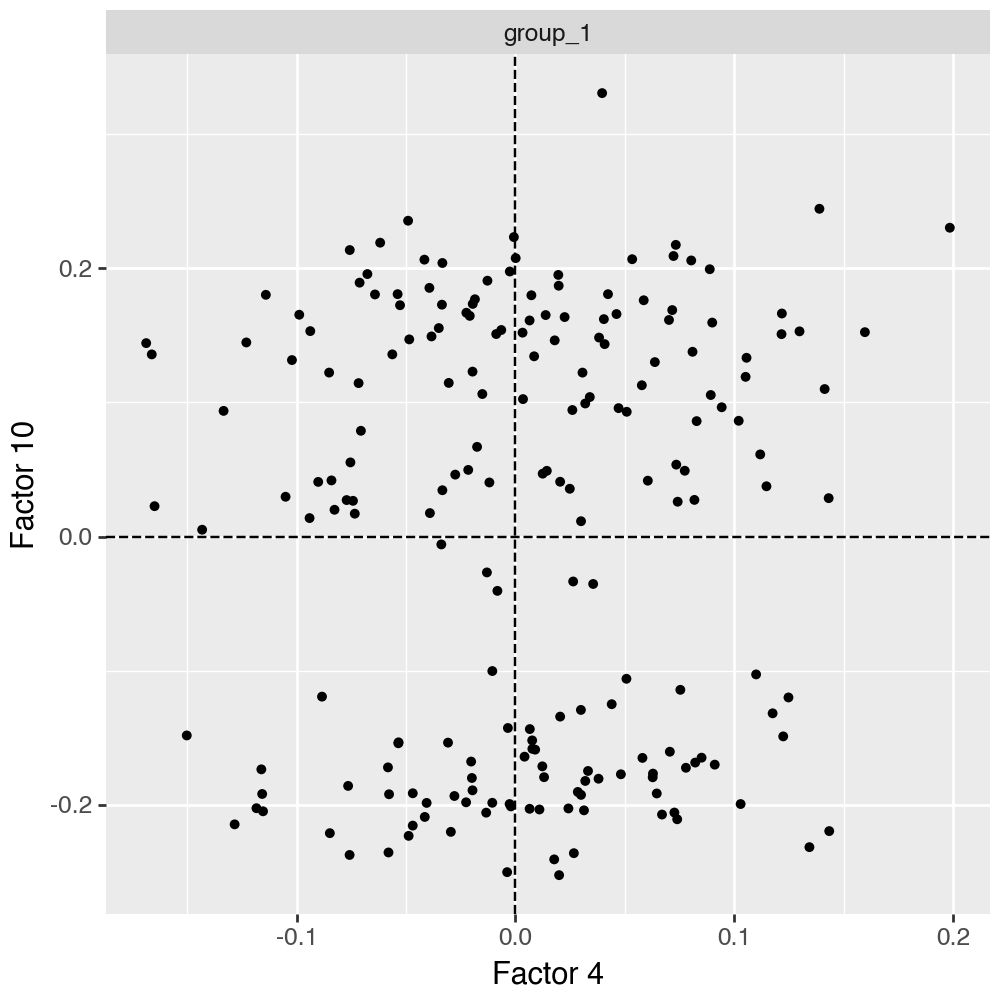

In [41]:
mfl.pl.factors_scatter(model, x="Factor 4", y="Factor 10")

#### Exercise
1. Identify two uncorrelated factors using the factor correlation plot from earlier.
2. Create a scatter plot of their factor scores using the factors_scatter function. Does the distribution confirm that they are uncorrelated?
3. Find highly correlated or anticorrelated factors and plot their scores. How strong is the relationship?

In [42]:
# Exercise 1
# 3 and 5 have relatively high correlation
# 7 and 5 have relatively low correlation

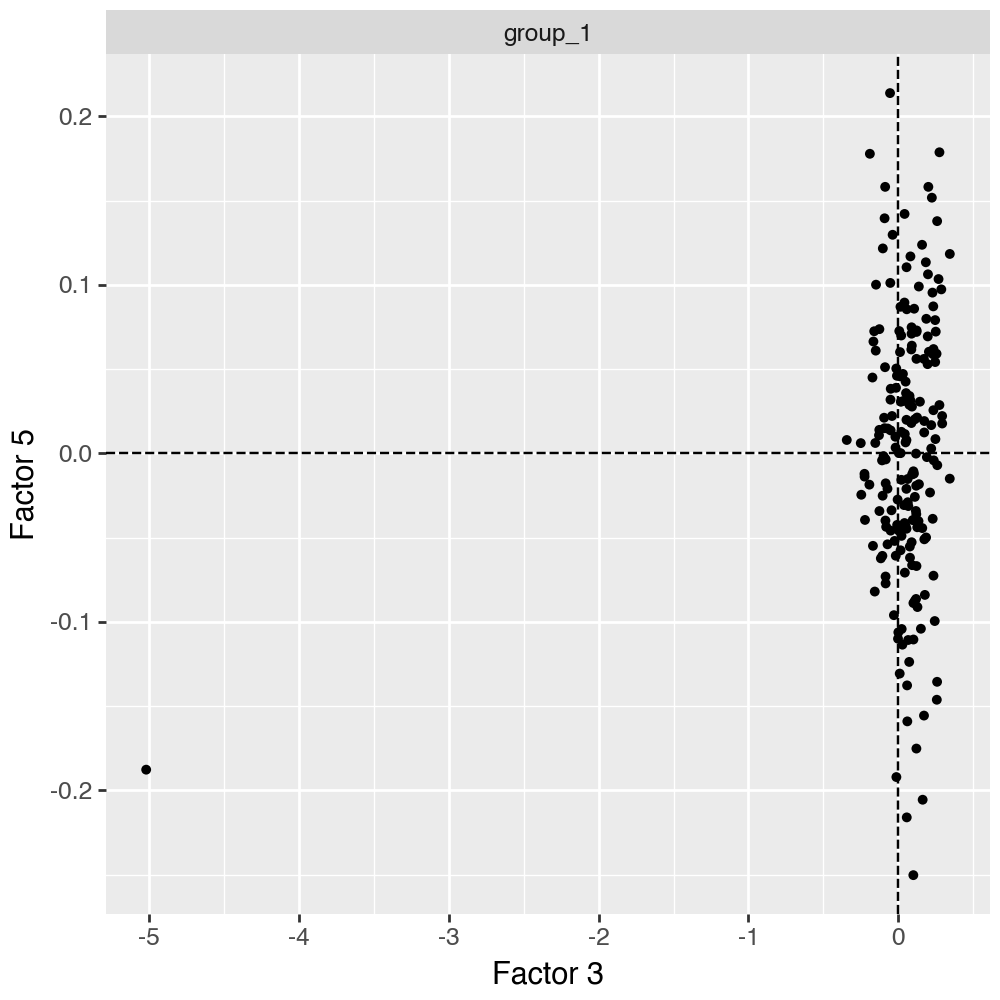

In [43]:
# Exercise 2
mfl.pl.factors_scatter(model, x="Factor 3", y="Factor 5")

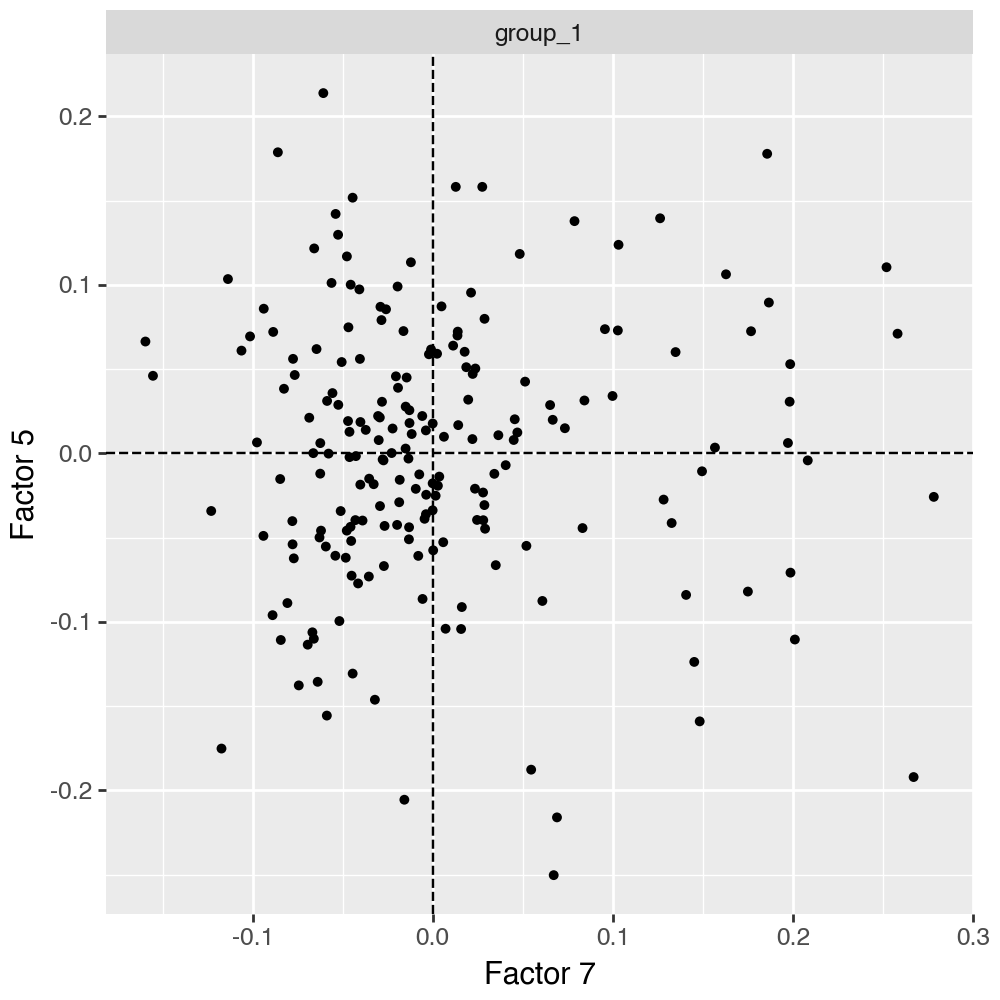

In [44]:
mfl.pl.factors_scatter(model, x="Factor 7", y="Factor 5")

Some factors may naturally separate samples into distinct groups. These factors are often particularly interesting, because they tell us something about the biological differences between those samples. It’s useful to check whether these groups correspond to known metadata by coloring the dots in the scatter plot accordingly.

As you can see in the next code cell, Factor 10 differentiates patients based on IGHV mutation status.

<Axes: xlabel='IGHV', ylabel='Factor 10'>

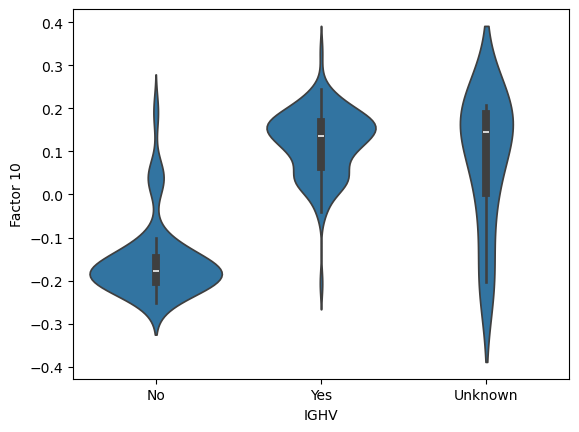

In [45]:
factor_scores["IGHV"] = metadata_df.loc[factor_scores.index]["IGHV"].map({-1: "Unknown", 0: "No", 1: "Yes"})
sns.violinplot(data=factor_scores, x="IGHV", y="Factor 10")

#### Exercise
1. Make violin plots to find a factor that distinguishes patients by their trisomy 12 status.
2. Make a scatter plot with a factor on one axis that separates patients by IGHV status and a factor on another axis that separates them by trisomy 12 status. Color the plot by IGHV / trisomy 12 status.
3. How many groups of patients seem to be present in the data set according to these factors?

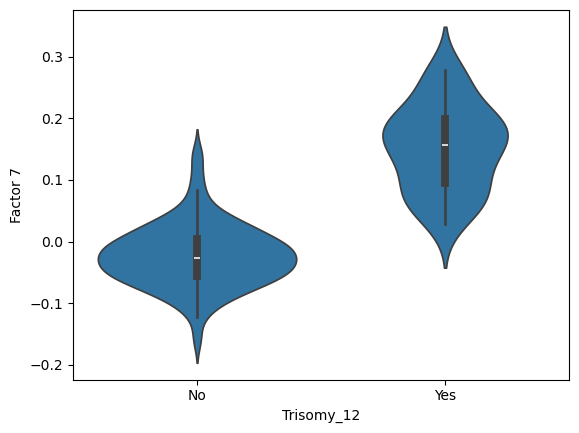

In [50]:
# Exercise 1
factor_scores["Trisomy_12"] = modality_dict["mutations"].to_df()["m_trisomy12"].map({-1: "Unknown", 0: "No", 1: "Yes"})
sns.violinplot(data=factor_scores, x="Trisomy_12", y="Factor 7")
plt.show()

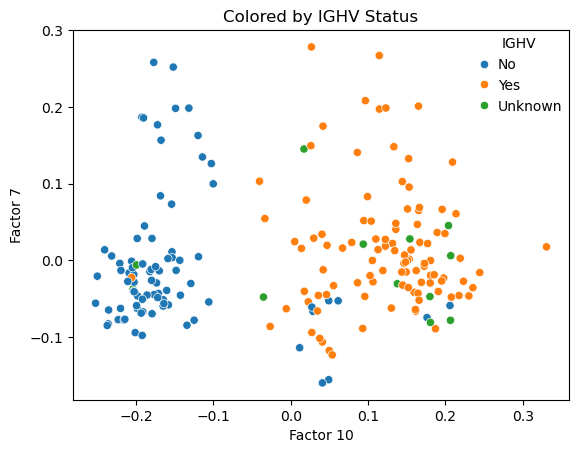

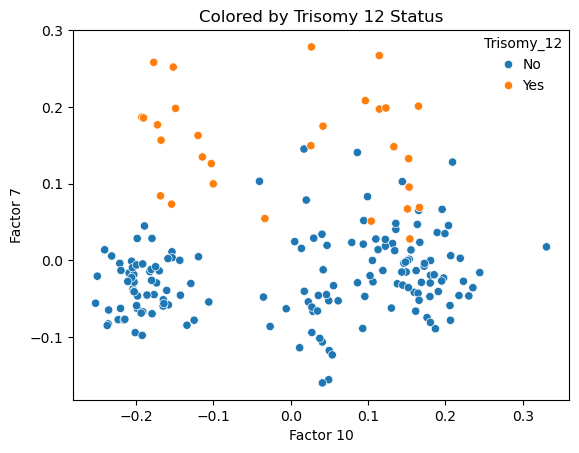

In [51]:
# Exercise 2
sns.scatterplot(factor_scores, x="Factor 10", y="Factor 7", hue=factor_scores["IGHV"])
plt.title("Colored by IGHV Status")
plt.show()

sns.scatterplot(factor_scores, x="Factor 10", y="Factor 7", hue=factor_scores["Trisomy_12"])
plt.title("Colored by Trisomy 12 Status")
plt.show()

In [52]:
# Exercise 4
# There seem to be four groups of patients which can be defined by their IGHV and Trisomy 12 status

#### Exercise

This one might be a bit more challenging. You've seen in the plot above that Factor 10 separates samples by their IGHV status. However, there are a few samples for which we do not have this information (we set their value to -1 in the beginning). Try to use a simple machine learning algorithm for classification (I would suggest [KNN Classification](https://scikit-learn.org/stable/modules/neighbors.html#nearest-neighbors-classification)) to determine these patients' IGHV status. Hint: First, train the KNN model on the factor scores without the missing samples and then use it to predict the IGHV status of the missing samples.

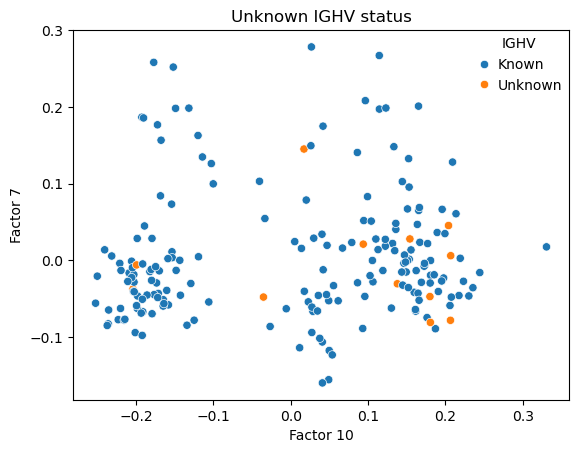

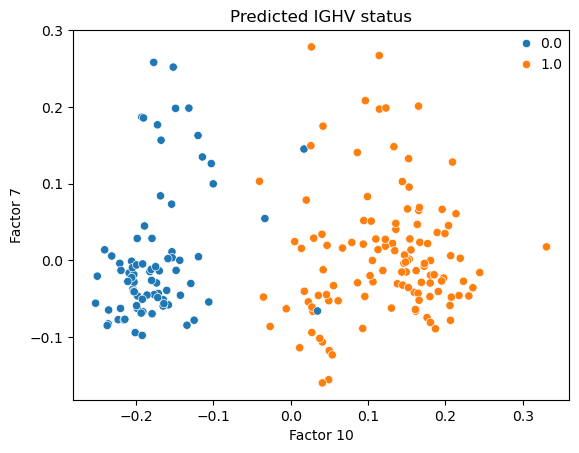

In [59]:
from sklearn.neighbors import KNeighborsClassifier

factors = model.get_factors()["group_1"]
ighv_labels = metadata_df.loc[factors.index]["IGHV"]

# we first split the patients in a group where we know IGHV status and one where we don't
factors_train = factors[ighv_labels.isin([0, 1])]
factors_test = factors[ighv_labels == -1]
status_train = ighv_labels[ighv_labels.isin([0, 1])]
# status_test = ?

# now we train a classifier with the training data
classifier = KNeighborsClassifier().fit(factors_train, status_train)

# and use the classifier to predict IGHV status on the test data (where we don't know it)
status_predict = classifier.predict(factors)

# we can plot the results
ighv_unknown = (ighv_labels==-1).map({False: "Known", True: "Unknown"})
sns.scatterplot(factors, x="Factor 10", y="Factor 7", hue=ighv_unknown, legend=True)
plt.title("Unknown IGHV status")
plt.show()

sns.scatterplot(factors, x="Factor 10", y="Factor 7", hue=status_predict)
plt.title("Predicted IGHV status")
plt.show()

## Downstream Analysis Part II - Understanding the factor loadings
So far, we've observed that:

- One factor is important across all modalities and likely captures general variation between patients.
- The same factor helps separate patients with and without IGHV mutation.
- Another factor helps distinguish patients with and without trisomy 12.

Now, let’s dive deeper into these factors by examining their factor loadings in the different modalities.

Factor loadings (or weights) describe how strongly each variable in a modality contributes to a factor. By analyzing these loadings, we can link specific variables to the factors and understand their biological relevance.

In [60]:
factor_loadings_mrna = model.get_weights()["mrna"]
factor_loadings_drugs = model.get_weights()["drugs"]
factor_loadings_methylation = model.get_weights()["methylation"]
factor_loadings_mutations = model.get_weights()["mutations"]

These factor loadings can be visualised with heatmaps as well:

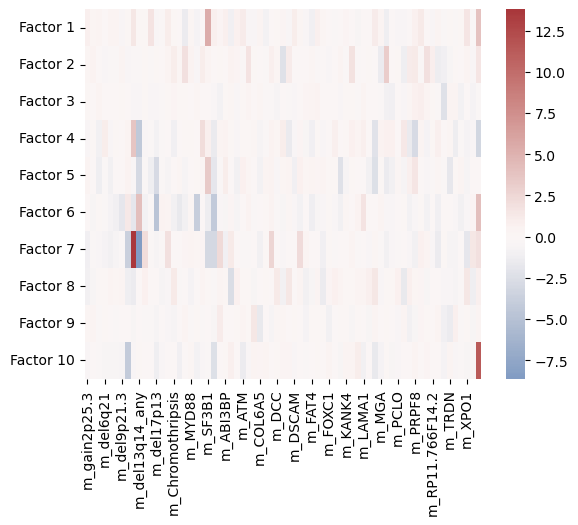

In [62]:
sns.heatmap(factor_loadings_mutations, cmap="vlag", center=0)
plt.show()

Or, alternatively as a scatter plot:

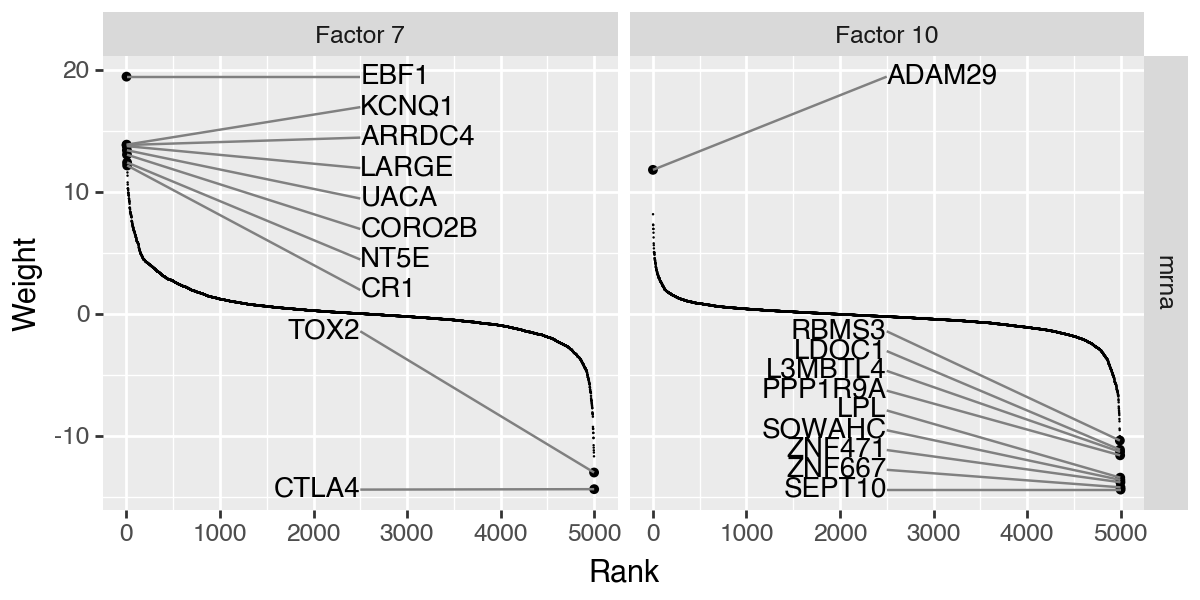

In [63]:
mfl.pl.weights(
    model,
    views=["mrna"],
    factors=["Factor 10", "Factor 7"]
)

#### Exercise

1. Check the factor loadings for the previously identified important factors in the mutations modality. What do you expect regarding the IGHV and trisomy 12 variables?
2. The formula for the factorisation is $$y_{nd} = \sum_d w_{dk} z_{nk},$$ where $y_{nd}$ is the data value of observation $n$ and variable $d$, $w_{dk}$ is the factor loading of variable $d$ and factor $k$, and $z_{nk}$ is the factor score of sample $n$ and factor $k$. If a variable has a high positive value in a sample, and the corresponding factor score is also positive, what does this imply for the sign of the factor loading? Validate your assumption by looking at the factor that separates samples by their IGHV status (remember how we encoded the IGHV mutation numerically).
3. We've seen that one factor has high values for patients with IGHV mutation. Have a look at the factor loadings for the same factor in other modalities (like transcriptome or drug response) now. What does it mean for a variable to have a high positive or negative loading? Can you create hypotheses about potential drug targets or drug efficacy?

In [64]:
# Exercise 1
print(factor_loadings_mutations.iloc[0].sort_values(ascending=False))
print(factor_loadings_mutations.iloc[1].sort_values(ascending=False))

m_SF3B1         5.397026
m_IGHV          3.951365
m_del15q15.1    1.691058
m_XPO1          1.541350
m_trisomy12     1.476155
                  ...   
m_CPS1         -0.860189
m_FAT4         -1.149363
m_ACTN2        -1.158610
m_MUC16        -1.196988
m_KRAS         -1.509275
Name: Factor 1, Length: 69, dtype: float32
m_MUC16      3.169052
m_RASGRF2    1.936328
m_KRAS       1.858076
m_KDM6B      1.744937
m_BIRC3      1.640721
               ...   
m_SEMA4D    -1.093036
m_POT1      -1.255635
m_RYR2      -1.276943
m_MGA       -1.449626
m_DNAH17    -2.283439
Name: Factor 2, Length: 69, dtype: float32


In [67]:
# Exercise 2
# Patients with IGHV mutations (encoded as "1") have positive Factor 10 scores, so to get the "1" we also expect the weight to be positive.

In [68]:
# Exercise 3
# In general, when the product of factor score and loading is large, the corresponding feature in the sample should also be large.

Finally, let us try to link the individual factors to some known biological processes. This can be done using gene set enrichment analysis, a technique that takes as input a number of genes and searches a data base to identify biological processes (or anything else, depends on the data base) that involve roughly this set of genes. To do this, we use the absolute values of the factor loadings (or weights), because the larger the absolute value the more important the gene is. We use the [decoupler package](https://decoupler.readthedocs.io/en/latest/).

In [69]:
# load the data base
net = dc.op.hallmark()

# run gene set enrichment analysis
es, pvals = dc.mt.gsea(data=factor_loadings_mrna.abs(), net=net)

In [70]:
es

,ADIPOGENESIS,ALLOGRAFT_REJECTION,ANDROGEN_RESPONSE,ANGIOGENESIS,APICAL_JUNCTION,APICAL_SURFACE,APOPTOSIS,BILE_ACID_METABOLISM,CHOLESTEROL_HOMEOSTASIS,COAGULATION,...,PROTEIN_SECRETION,REACTIVE_OXYGEN_SPECIES_PATHWAY,SPERMATOGENESIS,TGF_BETA_SIGNALING,TNFA_SIGNALING_VIA_NFKB,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_DN,UV_RESPONSE_UP,WNT_BETA_CATENIN_SIGNALING,XENOBIOTIC_METABOLISM
Factor 1,1.014768,0.950107,1.208577,1.394978,1.205038,1.293452,1.109561,1.070296,0.860941,0.925312,...,1.074241,0.694756,0.950563,1.155113,0.883524,0.846393,1.095326,0.685207,1.278443,1.031752
Factor 2,0.952987,1.073203,0.773389,1.055612,0.895911,1.043613,1.371462,0.849356,1.300393,0.862227,...,1.064232,1.240137,1.085381,1.204090,1.580728,1.556714,1.189928,1.481539,1.174100,1.130005
Factor 3,0.971979,1.349471,1.205670,1.237943,1.013489,1.223054,1.152681,1.105325,1.139351,1.277715,...,1.126879,1.108009,0.810852,1.104010,1.187802,0.876022,1.071750,0.974669,0.834036,1.254593
Factor 4,0.876431,1.595409,1.163503,1.204285,1.092545,1.209501,1.124393,0.764873,1.056706,1.003432,...,1.147714,1.021718,1.065538,1.040916,0.922394,0.713632,1.140076,0.605384,1.155166,0.930559
Factor 5,1.151565,0.708785,0.883493,1.263693,1.110038,1.098599,0.854392,1.351736,1.141009,1.059598,...,1.071048,0.931471,1.086386,0.855360,0.930895,0.958482,1.232653,1.206535,1.282421,0.814794
Factor 6,1.066894,1.074234,1.396082,1.310368,1.219164,-0.750403,1.107702,0.979687,1.343266,1.007509,...,1.383983,0.803895,0.868013,1.233633,0.831267,0.924625,1.035209,0.931814,1.125811,0.918962
Factor 7,1.116408,0.940671,1.339835,1.171037,1.076434,0.586782,0.970935,1.322840,0.872701,0.549594,...,1.149442,1.290773,1.000136,1.139381,1.073143,0.665128,1.131612,0.969783,1.192547,0.943988
Factor 8,1.005123,0.985474,0.763583,1.006880,0.784374,0.876189,1.113056,0.854558,1.118959,1.010945,...,0.790155,1.101953,0.978249,0.921439,1.149853,1.186564,0.764215,1.154579,0.927594,1.034354
Factor 9,1.158559,0.965969,1.213038,1.016489,0.969933,1.007556,1.300241,0.937789,1.185085,1.079116,...,1.215292,0.766461,1.322733,1.382685,1.351999,1.520701,1.098116,1.333248,0.999045,1.018749
Factor 10,1.268617,0.916759,1.085933,1.532848,1.035293,1.097287,1.158970,0.996166,0.988771,0.782425,...,0.831825,1.003060,1.013206,0.677818,0.774031,0.665439,1.089948,0.839365,1.350493,0.682791


#### Exercise
1. How can this table be interpreted? 
2. Sort the rows according to the values of individual factors. Is there a factor for which the top gene sets share a common theme?
3. Try doing the same analysis with a different gene set collection.

In [71]:
# Exercise 1
# The individual values give an idea of how strongly a factor (based on its loadings) is associated with a gene set / pathway / ...

In [72]:
# Exercise 2
pvals.T["Factor 7"].sort_values(ascending=True)

ANDROGEN_RESPONSE                    0.212500
BILE_ACID_METABOLISM                 0.212500
NOTCH_SIGNALING                      0.212500
EPITHELIAL_MESENCHYMAL_TRANSITION    0.212500
IL6_JAK_STAT3_SIGNALING              0.241667
HYPOXIA                              0.241667
IL2_STAT5_SIGNALING                  0.371429
PEROXISOME                           0.444639
MITOTIC_SPINDLE                      0.533638
REACTIVE_OXYGEN_SPECIES_PATHWAY      0.533638
ESTROGEN_RESPONSE_LATE               0.533638
MTORC1_SIGNALING                     0.552192
WNT_BETA_CATENIN_SIGNALING           0.552192
HEDGEHOG_SIGNALING                   0.552192
ESTROGEN_RESPONSE_EARLY              0.552192
TNFA_SIGNALING_VIA_NFKB              0.552192
UV_RESPONSE_DN                       0.552192
ANGIOGENESIS                         0.552192
GLYCOLYSIS                           0.560000
ADIPOGENESIS                         0.560000
COMPLEMENT                           0.565217
TGF_BETA_SIGNALING                

In [80]:
# Exercise 3
net = dc.op.dorothea()
es, pvals = dc.mt.gsea(data=factor_loadings_mrna.abs(), net=net)

In [81]:
pvals.T["Factor 7"].sort_values(ascending=True)

TP53      0.000000
CEBPA     0.000000
EGR1      0.000000
FOXA1     0.000000
POU2F2    0.027920
            ...   
ZBTB33    0.963027
SP4       0.988292
HNF1A     0.990676
FOXO4     0.990676
FOXL2     0.990676
Name: Factor 7, Length: 246, dtype: float64

With this, you gained quite some insight in training and analysing a MOFA model. The official part of the project is now over, hopefully you enjoyed it and learned something useful for your own research! But feel free to try out more things, there's a lot to explore and you could also look at other public multi-omics data sets and maybe find something interesting?

#### Additional Exercises (if you have time and according to your interests)
1. Browse the [MOFA-FLEX documentation](mofaflex.readthedocs.io)
2. What is MEFISTO about? If you're interested, read [the paper](https://www.nature.com/articles/s41592-021-01343-9).
3. Find another public Multi-Omics dataset and apply MOFA-FLEX (look for example [here](https://github.com/PMBio/mudatasets/tree/main/mudatasets/datasets))
4. If you want to deep dive in developing your own factor models, have a look at the probabilistic programming language [Pyro](https://pyro.ai/). You can find a very basic factor model to build on, implemented in Pyro, [here](https://github.com/florinwalter/pyro_models/blob/main/src/models/factor_analysis.py).